# CPE382 Final Exam #

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy
import skimage
import sklearn
import os
import glob

# Segmentation and Binary Mask #

## Original Image and Histogram ##

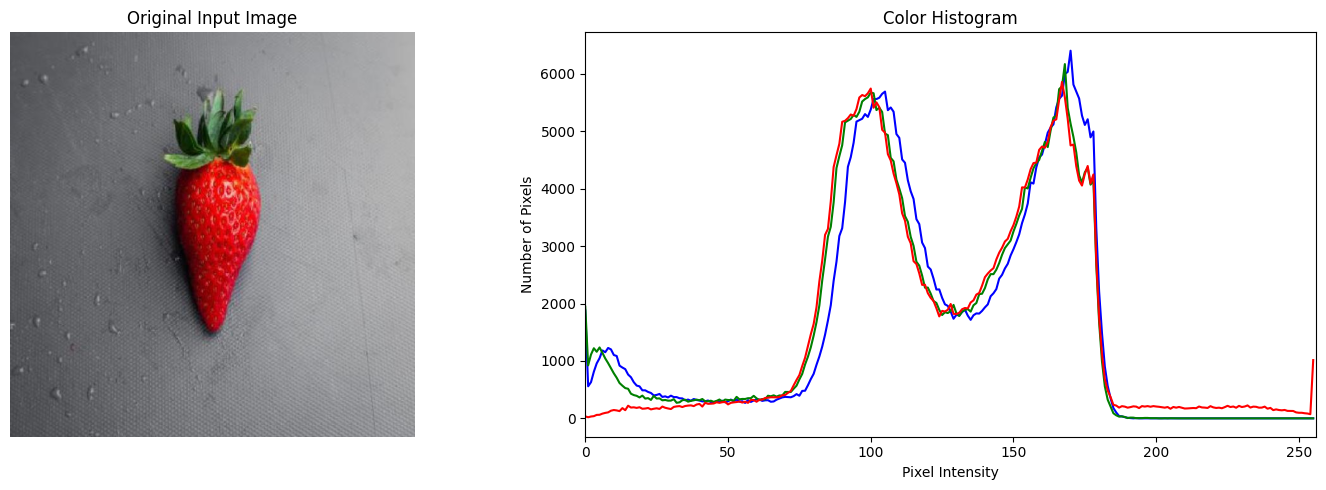

In [3]:
#Load image
img_path = './img/Normal_Strawberries.jpg' 
img = cv2.imread(img_path)
#Histogram of image
colors = ('b', 'g', 'r')


if img is None:
    print(f"Error: Could not read image at '{img_path}'.")
else:
    # 2. Setup the subplot layout
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # 3. Display original image on the left (axes[0])
    # Convert BGR to RGB so the strawberry looks red, not blue!
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) 
    axes[0].set_title('Original Input Image')
    axes[0].axis('off') # Optional: hides the axis ticks for a cleaner look

    # 4. Calculate and plot the histogram on the right (axes[1])
    colors = ('b', 'g', 'r')
    for i, col in enumerate(colors):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        axes[1].plot(hist, color=col) # Plot directly onto axes[1]
        
    axes[1].set_title('Color Histogram')
    axes[1].set_xlim([0, 256])
    axes[1].set_xlabel('Pixel Intensity')
    axes[1].set_ylabel('Number of Pixels')

    # 5. Render the result
    plt.tight_layout() # Prevents titles/labels from overlapping
    plt.show()

## Global Thresholding vs Color Thresholding ##

### Global gray scale Thresholding ###

(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

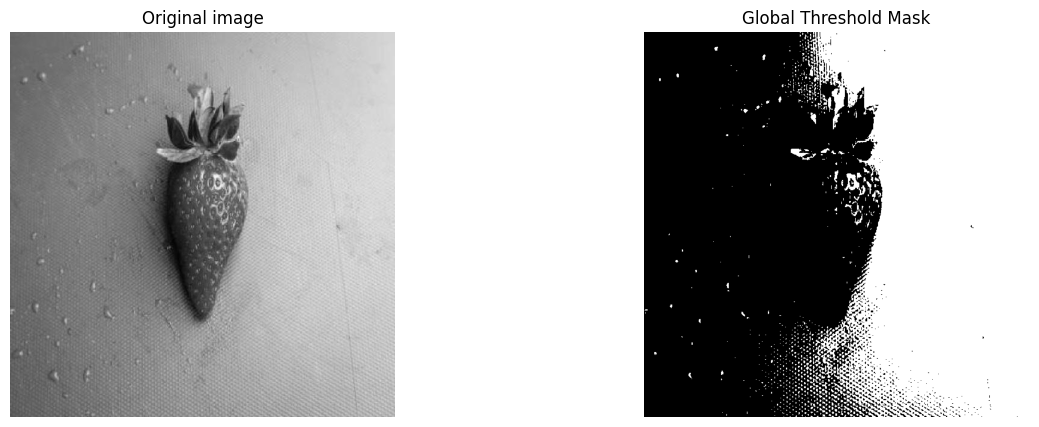

In [4]:
#Convert original img to grayscale
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#applied global threshold
ret, binary_mask_global = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)
#Show images
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
#Original images
axes[0].imshow(gray_image, cmap = 'gray')
axes[0].set_title("Original image")
axes[0].axis('off')
#after applied thresholding
axes[1].imshow(binary_mask_global, cmap='gray')
axes[1].set_title('Global Threshold Mask')
axes[1].axis('off')

### Color Thresholding (HSV) ###

(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

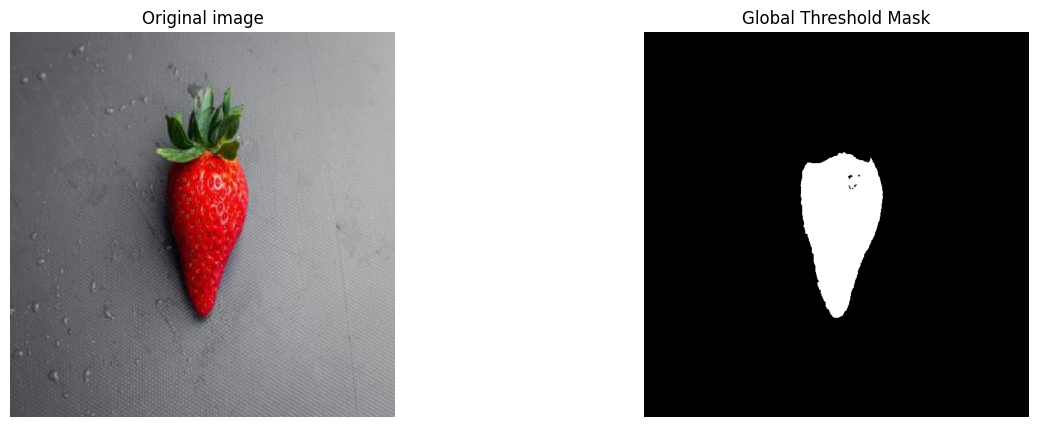

In [5]:
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower_red1 = np.array([0, 100, 20])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 100, 20])
upper_red2 = np.array([179, 255, 255])

mask1 = cv2.inRange(hsv_img, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv_img, lower_red2, upper_red2)

# Combine the two masks to capture all shades of red
binary_mask_color = mask1 | mask2

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
#Original images
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original image")
axes[0].axis('off')
#after applied thresholding
axes[1].imshow(binary_mask_color, cmap='gray')
axes[1].set_title('Global Threshold Mask')
axes[1].axis('off')

### Segmentation Results Comparison ###

(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

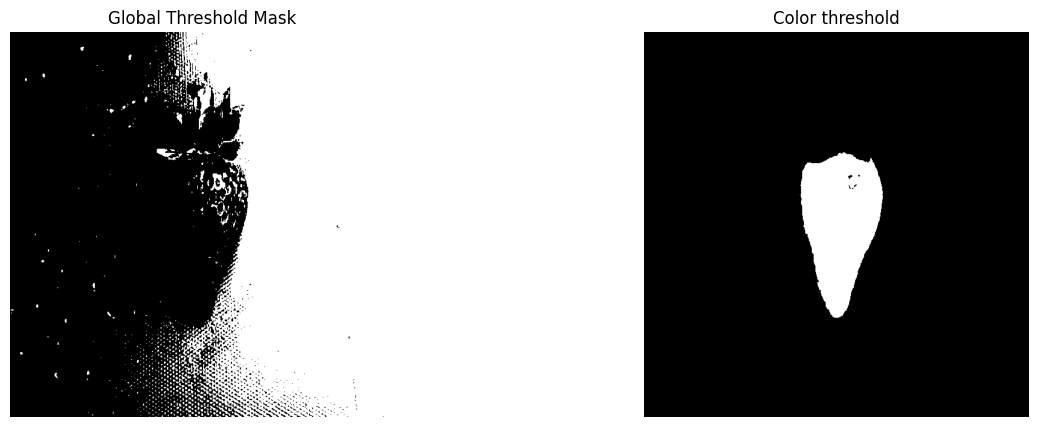

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
#Original images
axes[0].imshow(binary_mask_global, cmap='gray')
axes[0].set_title('Global Threshold Mask')
axes[0].axis('off')
#after applied thresholding
axes[1].imshow(binary_mask_color, cmap='gray')
axes[1].set_title('Color threshold')
axes[1].axis('off')

## Apply morphological operations ##

### Global Thresholding Morph ###

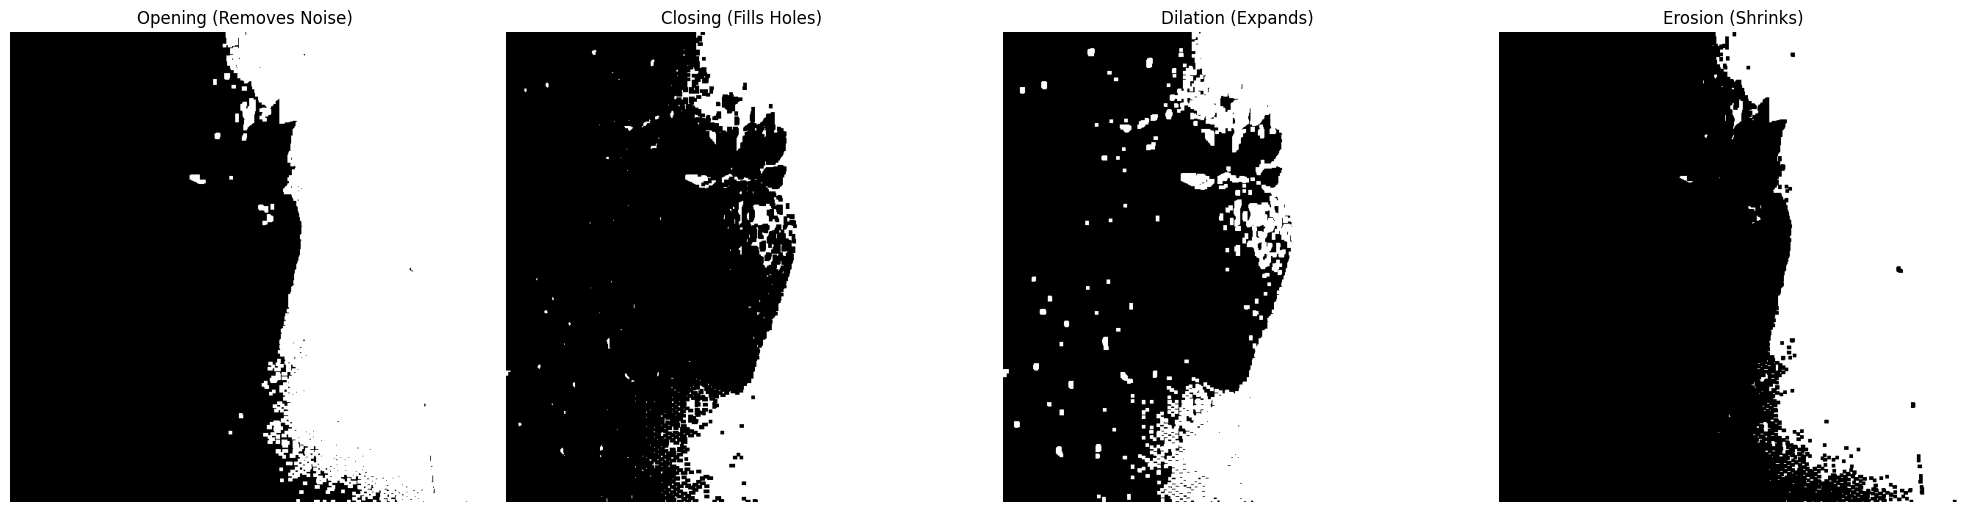

In [8]:
#Define kernel 
k = np.ones((5, 5), np.uint8)  # 3x3 kernel
opened_Global = cv2.morphologyEx(binary_mask_global, cv2.MORPH_OPEN, k)
closing_Global = cv2.morphologyEx(binary_mask_global, cv2.MORPH_CLOSE, k)
dilation_Global = cv2.morphologyEx(binary_mask_global, cv2.MORPH_DILATE, k)
erosion_Global = cv2.morphologyEx(binary_mask_global, cv2.MORPH_ERODE, k)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 1. Opening Result
axes[0].imshow(opened_Global, cmap='gray')
axes[0].set_title('Opening (Removes Noise)')
axes[0].axis('off')

# 2. Closing Result
axes[1].imshow(closing_Global, cmap='gray')
axes[1].set_title('Closing (Fills Holes)')
axes[1].axis('off')

# 3. Dilation Result
axes[2].imshow(dilation_Global, cmap='gray')
axes[2].set_title('Dilation (Expands)')
axes[2].axis('off')

# 4. Erosion Result
axes[3].imshow(erosion_Global, cmap='gray')
axes[3].set_title('Erosion (Shrinks)')
axes[3].axis('off')

# Display everything cleanly
plt.tight_layout()
plt.show()


### Color thresholding Morph ###

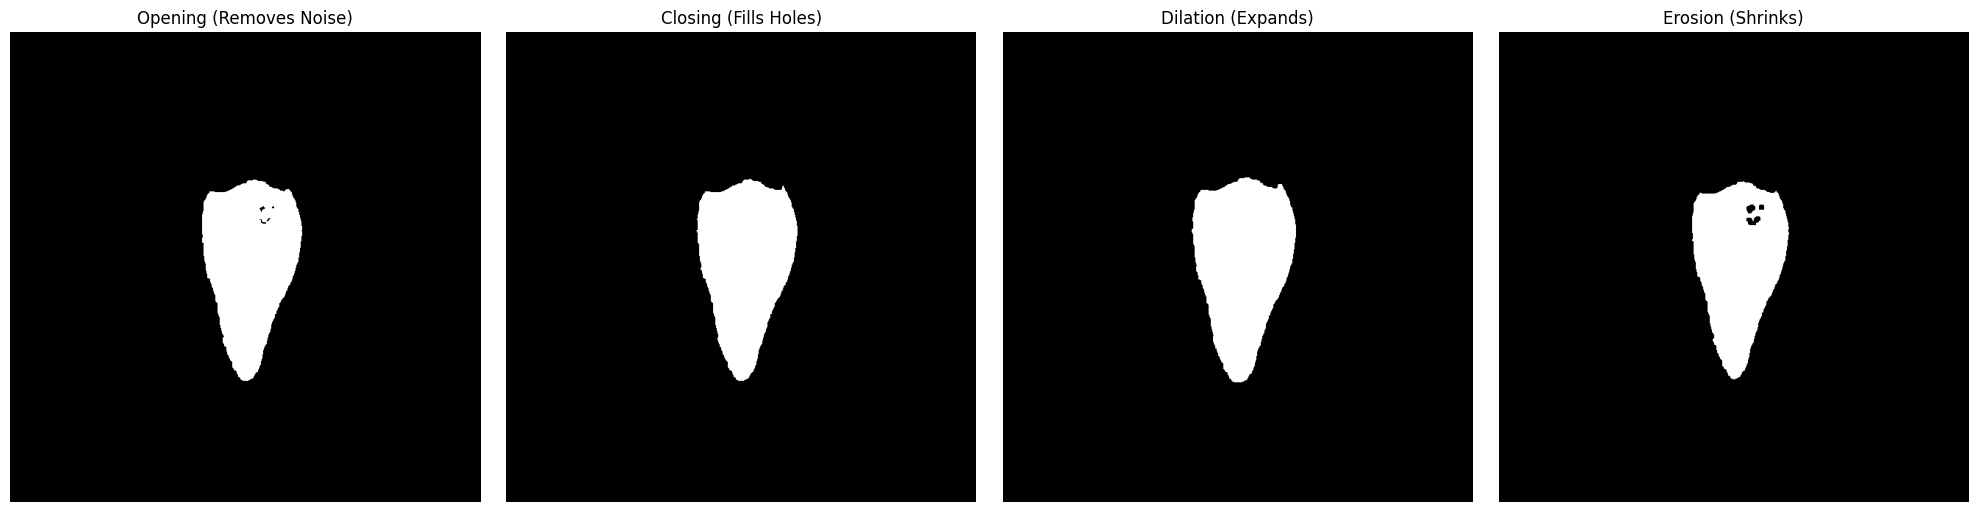

In [9]:
#Define kernel 
k = np.ones((5, 5), np.uint8)  # 3x3 kernel
opened_Color = cv2.morphologyEx(binary_mask_color, cv2.MORPH_OPEN, k)
closing_Color = cv2.morphologyEx(binary_mask_color, cv2.MORPH_CLOSE, k)
dilation_Color = cv2.morphologyEx(binary_mask_color, cv2.MORPH_DILATE, k)
erosion_Color = cv2.morphologyEx(binary_mask_color, cv2.MORPH_ERODE, k)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 1. Opening Result
axes[0].imshow(opened_Color, cmap='gray')
axes[0].set_title('Opening (Removes Noise)')
axes[0].axis('off')

# 2. Closing Result
axes[1].imshow(closing_Color, cmap='gray')
axes[1].set_title('Closing (Fills Holes)')
axes[1].axis('off')

# 3. Dilation Result
axes[2].imshow(dilation_Color, cmap='gray')
axes[2].set_title('Dilation (Expands)')
axes[2].axis('off')

# 4. Erosion Result
axes[3].imshow(erosion_Color, cmap='gray')
axes[3].set_title('Erosion (Shrinks)')
axes[3].axis('off')

# Display everything cleanly
plt.tight_layout()
plt.show()


# Feature Extraction #

### Preprocessing and segmentation function ###

In [10]:
def preprocess_and_segment(image_path):
    print(f"\nProcessing: {image_path}")
    
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load {image_path}")
        return None, None, None # Return three Nones if it fails
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # 1. Color Thresholding (Isolate Red/Brown hues)
    lower_red1 = np.array([0, 100, 20])
    upper_red1 = np.array([20, 255, 255])
    lower_red2 = np.array([160, 100, 20])
    upper_red2 = np.array([179, 255, 255])
    
    mask1 = cv2.inRange(hsv_img, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv_img, lower_red2, upper_red2)
    binary_mask_color = mask1 | mask2 
    
    # 2. Morphological Closing (Fill holes)
    k = np.ones((5, 5), np.uint8)
    closing_Color = cv2.morphologyEx(binary_mask_color, cv2.MORPH_CLOSE, k)

    # Return the Mask AND the original images needed for Feature Extraction!
    return closing_Color, img_rgb, img

### Prepared Defect image ###

In [11]:
# Process the Defective Strawberries
mask_n, img_rgb_n, img_bgr_n = preprocess_and_segment('img/Normal_Strawberries.jpg')
mask_d1, img_rgb_d1, img_bgr_d1 = preprocess_and_segment('img/Defect_Straberries.jpg')
mask_d2, img_rgb_d2, img_bgr_d2 = preprocess_and_segment('img/Defect_Strawberry_2.jpg')


Processing: img/Normal_Strawberries.jpg

Processing: img/Defect_Straberries.jpg

Processing: img/Defect_Strawberry_2.jpg


### Features Extraction Function ###

In [12]:
# Features extraction function
def Features_Extraction(mask, img):
    # Find contours using the passed-in mask!
    contours, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Prepare images for visualization 
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    contour_img = img_rgb.copy()
    keypoint_img = img_rgb.copy()

    # Local feature detector
    orb = cv2.ORB_create()
    
    # Create a list to save the data for Part 3
    features_list = []

    for i, contour in enumerate(contours):
        # Filter out tiny noise contours by area
        if cv2.contourArea(contour) < 500:
            continue
            
        # ==========================================
        # FEATURE 1: SHAPE FEATURES
        # ==========================================
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
    
        # Calculate Circularity
        if perimeter > 0:
            circularity = (4 * np.pi * area) / (perimeter ** 2)
        else:
            circularity = 0
            
        cv2.drawContours(contour_img, [contour], -1, (0, 255, 0), 3)

        # ==========================================
        # FEATURE 2: COLOR FEATURES (Mean RGB)
        # ==========================================
        single_obj_mask = np.zeros_like(mask)
        cv2.drawContours(single_obj_mask, [contour], -1, 255, thickness=cv2.FILLED)
    
        mean_val = cv2.mean(img_rgb, mask=single_obj_mask)
        mean_R, mean_G, mean_B = mean_val[0], mean_val[1], mean_val[2]

        # ==========================================
        # FEATURE 3: LOCAL FEATURES (Keypoints/Corners)
        # ==========================================
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        masked_gray = cv2.bitwise_and(gray_img, gray_img, mask=single_obj_mask)
    
        keypoints = orb.detect(masked_gray, None)
        num_keypoints = len(keypoints)
        
        cv2.drawKeypoints(keypoint_img, keypoints, keypoint_img, color=(255, 0, 0), flags=0)
        
        # Save the calculated numbers!
        features_list.append({
            'area': area,
            'circularity': circularity,
            'mean_R': mean_R,
            'keypoints': num_keypoints
        })

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    axes[0].imshow(contour_img)
    axes[0].set_title('Extracted Object Contours')
    axes[0].axis('off')

    axes[1].imshow(keypoint_img)
    axes[1].set_title(f'Detected Keypoints (Texture)')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    
    # Hand the data back to the main script
    return features_list

### Final Results ###

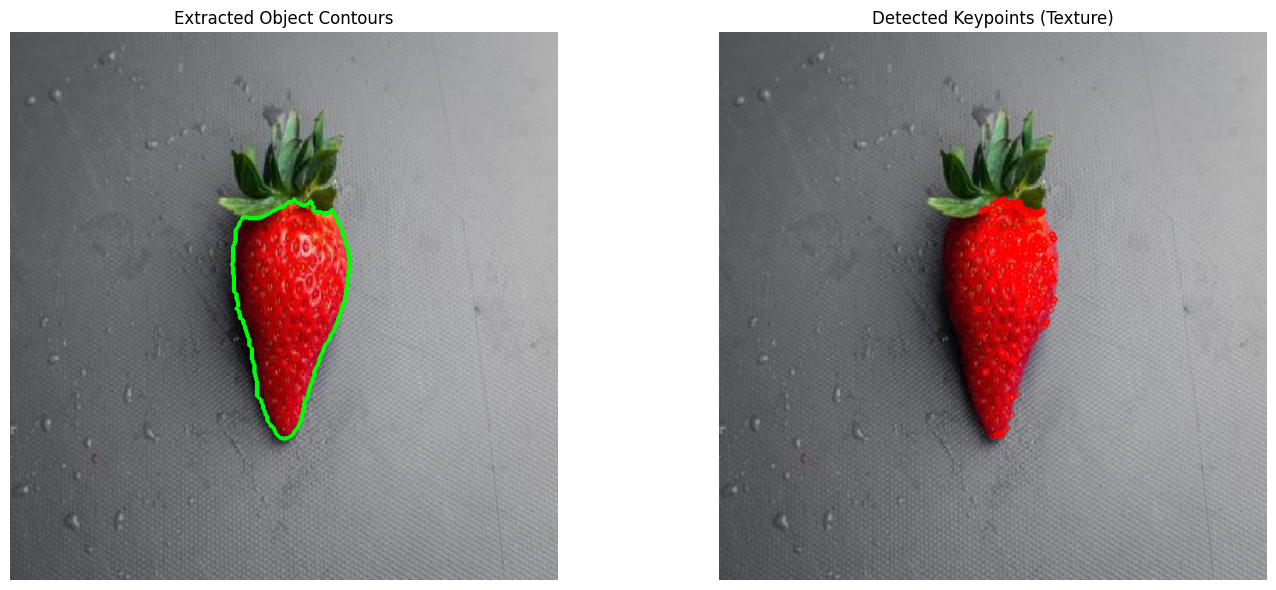

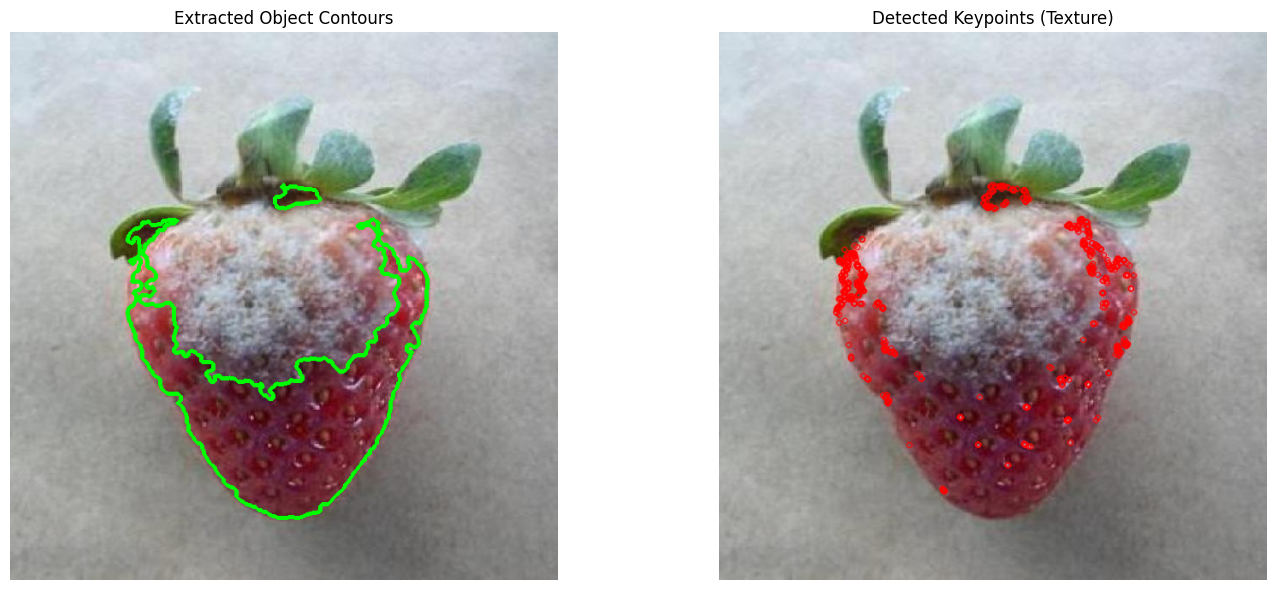

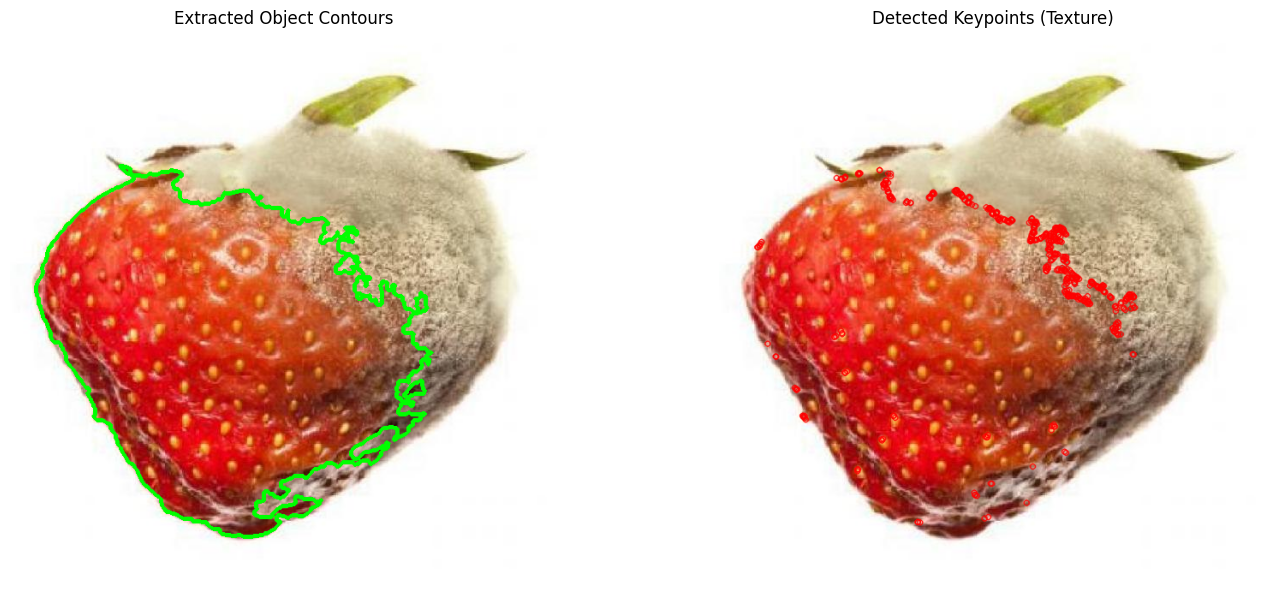

In [13]:
normal_data = Features_Extraction(mask_n, img_bgr_n)
defect1_data = Features_Extraction(mask_d1, img_bgr_d1)
defect2_data = Features_Extraction(mask_d2, img_bgr_d2)

# Defect Detection and Counting #

## Preprocessing Segmentation and Feature Extraction ##

In [25]:
def preprocess_and_segment(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None, None, None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Initialize mask as None to prevent crashes
    mask = None

    # Check the filename to decide which color to look for!
    # (Notice I added 'or' to catch the spelling typos in your folder!)
    if "Strawberry" in image_path or "Strawberries" in image_path:
        # Red wraps around the HSV scale! We need BOTH sides.
        lower1 = np.array([0, 100, 20])
        upper1 = np.array([20, 255, 255])
        mask1 = cv2.inRange(hsv_img, lower1, upper1)
        
        lower2 = np.array([160, 100, 20])
        upper2 = np.array([179, 255, 255])
        mask2 = cv2.inRange(hsv_img, lower2, upper2)
        
        # Combine both masks together
        mask = mask1 | mask2
        
    elif "Mango" in image_path:
        lower = np.array([20, 100, 100])
        upper = np.array([30, 255, 255])
        mask = cv2.inRange(hsv_img, lower, upper)
        
    elif "Guava" in image_path:
        lower = np.array([35, 50, 50])
        upper = np.array([85, 255, 255])
        mask = cv2.inRange(hsv_img, lower, upper)
        
    elif "Pineapple" in image_path:
        lower = np.array([10, 50, 20])
        upper = np.array([85, 255, 230]) 
        mask = cv2.inRange(hsv_img, lower, upper)
        
    elif "Dragonfruit" in image_path:
        lower = np.array([145, 50, 50])
        upper = np.array([179, 255, 255])
        mask = cv2.inRange(hsv_img, lower, upper)
        
    # Added the Pear/Pair condition!
    elif "Pear" in image_path or "Pair" in image_path:
        lower = np.array([25, 40, 40])
        upper = np.array([45, 255, 255])
        mask = cv2.inRange(hsv_img, lower, upper)

    # Safety net: If the file name didn't match anything, skip it safely
    if mask is None:
        print(f"Skipping {image_path}: No color rules defined.")
        return None, None, None

    # Apply morphological closing to the newly created 'mask'
    k = np.ones((5, 5), np.uint8)
    closing_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)

    return closing_mask, img_rgb, img

In [27]:
# Features extraction function
def Features_Extraction(mask, img):
    # Find contours using the passed-in mask!
    contours, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Prepare images for visualization 
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    contour_img = img_rgb.copy()
    keypoint_img = img_rgb.copy()

    # Local feature detector
    orb = cv2.ORB_create(nfeatures=2000)
    
    # Create a list to save the data for Part 3
    features_list = []

    for i, contour in enumerate(contours):
        # Filter out tiny noise contours by area
        if cv2.contourArea(contour) < 5000:
            continue
            
        # ==========================================
        # FEATURE 1: SHAPE FEATURES
        # ==========================================
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
    
        # Calculate Circularity
        if perimeter > 0:
            circularity = (4 * np.pi * area) / (perimeter ** 2)
        else:
            circularity = 0
            
        cv2.drawContours(contour_img, [contour], -1, (0, 255, 0), 3)

        # ==========================================
        # FEATURE 2: COLOR FEATURES (Mean RGB)
        # ==========================================
        single_obj_mask = np.zeros_like(mask)
        cv2.drawContours(single_obj_mask, [contour], -1, 255, thickness=cv2.FILLED)
    
        mean_val = cv2.mean(img_rgb, mask=single_obj_mask)
        mean_R, mean_G, mean_B = mean_val[0], mean_val[1], mean_val[2]

        # ==========================================
        # FEATURE 3: LOCAL FEATURES (Keypoints/Corners)
        # ==========================================
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        masked_gray = cv2.bitwise_and(gray_img, gray_img, mask=single_obj_mask)
    
        keypoints = orb.detect(masked_gray, None)
        num_keypoints = len(keypoints)
        
        cv2.drawKeypoints(keypoint_img, keypoints, keypoint_img, color=(255, 0, 0), flags=0)
        
        # Save the calculated numbers!
        features_list.append({
            'area': area,
            'circularity': circularity,
            'mean_R': mean_R,
            'keypoints': num_keypoints
        })

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    axes[0].imshow(contour_img)
    axes[0].set_title('Extracted Object Contours')
    axes[0].axis('off')

    axes[1].imshow(keypoint_img)
    axes[1].set_title(f'Detected Keypoints (Texture)')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    
    # Hand the data back to the main script
    return features_list

## Results ##

In [ ]:
# Get all image files
image_files = glob.glob('img/*.jpg')

total_objects = 0
defective_objects = 0
total_area = 0

for file_path in image_files: 
    mask, img_rgb, img_bgr = preprocess_and_segment(file_path)

    if mask is not None:
        feature_list = Features_Extraction(mask, img_bgr)

        for obj in feature_list:
            total_objects += 1
            total_area += obj['area']
            
            # Create variables to track the bouncer's decision
            is_defective = False
            fruit_name = "Unknown"

            # ==========================================
            # THE VIP LIST: Fruit-Specific Bouncer Rules
            # ==========================================
            if "Strawberry" in file_path or "Straberries" in file_path:
                fruit_name = "Strawberry"
                if obj['circularity'] < 0.20 or obj['keypoints'] > 150:
                    is_defective = True
                    
            elif "Mango" in file_path:
                fruit_name = "Mango"
                # Mangoes are very smooth. High standards!
                if obj['circularity'] < 0.70 or obj['keypoints'] > 100:
                    is_defective = True
                    
            elif "Guava" in file_path:
                fruit_name = "Guava"
                if obj['circularity'] < 0.60 or obj['keypoints'] > 200:
                    is_defective = True
                    
            elif "Pineapple" in file_path:
                fruit_name = "Pineapple"
                # Very forgiving shape rule, very high keypoint tolerance!
                if obj['circularity'] < 0.15 or obj['keypoints'] > 1200:
                    is_defective = True
                    
            elif "Dragonfruit" in file_path:
                fruit_name = "Dragonfruit"
                # Forgive the black marker and the jagged scales!
                if obj['circularity'] < 0.20 or obj['keypoints'] > 1950:
                    is_defective = True
                    
            elif "Pear" in file_path or "Pair" in file_path:
                fruit_name = "Pear"
                # Give it room for natural speckles and shadow cutoffs
                if obj['circularity'] < 0.50 or obj['keypoints'] > 600:
                    is_defective = True

            # ==========================================
            # TALLY AND PRINT RESULTS
            # ==========================================
            if is_defective:
                defective_objects += 1
                print(f" -> Result: {fruit_name} is DEFECTIVE (Circularity: {obj['circularity']:.2f}, Keypoints: {obj['keypoints']})")
            else:
                print(f" -> Result: {fruit_name} is NORMAL (Circularity: {obj['circularity']:.2f}, Keypoints: {obj['keypoints']})")

# ==========================================
# FINAL EXAM REPORT
# ==========================================
print("\n" + "="*30)
print("FINAL EXAM REPORT")
print("="*30)
print(f"Total Objects: {total_objects}")
print(f"Defective Objects: {defective_objects}")

# Safety check to avoid dividing by zero if the folder is empty
if total_objects > 0:
    average_area = total_area / total_objects
    defect_percentage = (defective_objects / total_objects) * 100
    
    print(f"Average Area: {average_area:.0f} pixels")
    print(f"Defect Percentage: {defect_percentage:.2f}%")